# Simulated export analysis

This notebook reads the PsyNet bot export for the adaptive arithmetic CAT. The answers are simulated, not human.

In [1]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ["svg"]

here = Path.cwd()
root = here if (here / "experiment.py").exists() else here.parents[2]
export = root / "audit/simulate/analysis/simulated_export/regular/basic_data"
trials = pd.read_csv(export / "trial.csv")
participants = pd.read_csv(export / "participant.csv")
decisions = pd.read_csv(export / "adaptive_decision.csv")
print(root)
print("trials", len(trials), "participants", len(participants), "decisions", len(decisions))
trials.head()


/workspace/demos/experiments/adaptive_irt
trials 54 participants 3 decisions 48


,id,participant_id,item_id,difficulty,phase,answer,correct
0,51,3,mix_02,0.5,adaptive,9,0.0
1,1,1,add_sd_01,-2.0,practice,5,0.0
2,2,1,sub_sd_01,-1.7,practice,3,0.0
3,3,1,add_carry_01,0.1,adaptive,44,0.0
4,4,1,sub_td_03,-0.4,adaptive,7,0.0


## Participants

In [2]:
participants

,id,status,true_ability,response_profile,ability_mean,ability_sd
0,3,approved,1.4,inattentive,-0.415609,0.475641
1,1,approved,-1.2,good,-1.399757,0.503542
2,2,approved,0.3,good,0.282116,0.464948


## Adaptive decisions

In [3]:

adaptive = trials[trials.phase == "adaptive"].copy()
print("unique items per participant")
print(adaptive.groupby("participant_id").item_id.nunique())
print("decision rows match adaptive trials:", len(decisions) == len(adaptive))
decisions.head()


unique items per participant
participant_id
1    16
2    16
3    16
Name: item_id, dtype: int64
decision rows match adaptive trials: True


,id,participant_id,trial_id,selected_candidate_id,participant_history_count,selected_utility,ability_mean,ability_sd,predictive_p_correct
0,1,1,3,add_carry_01,0,0.206320,-4.330710e-17,0.999513,0.479347
1,2,1,4,sub_td_03,1,0.212244,-3.960481e-01,0.911177,0.501049
2,3,1,5,sub_td_01,2,0.216365,-7.486412e-01,0.843956,0.489822
3,4,1,6,add_td_01,3,0.218819,-1.049972e+00,0.792063,0.467541
4,5,1,7,sub_sd_02,4,0.218467,-1.306927e+00,0.750945,0.565205


## Item difficulty over the CAT

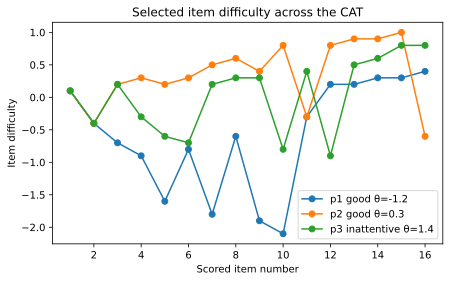

In [4]:

adaptive = adaptive.sort_values(["participant_id", "id"])
adaptive["cat_index"] = adaptive.groupby("participant_id").cumcount() + 1
fig, ax = plt.subplots(figsize=(7, 4))
for pid, group in adaptive.groupby("participant_id"):
    profile = participants.loc[participants.id == pid, "response_profile"].iloc[0]
    ability = participants.loc[participants.id == pid, "true_ability"].iloc[0]
    ax.plot(group.cat_index, group.difficulty, marker="o", label=f"p{pid} {profile} θ={ability}")
ax.set_xlabel("Scored item number")
ax.set_ylabel("Item difficulty")
ax.legend()
ax.set_title("Selected item difficulty across the CAT")
plt.show()


## Recovered vs stored ability

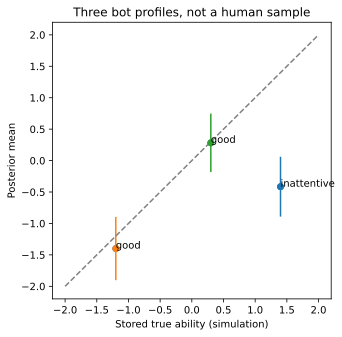

In [5]:

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(participants.true_ability, participants.ability_mean)
for _, row in participants.iterrows():
    ax.errorbar(row.true_ability, row.ability_mean, yerr=row.ability_sd, fmt="o")
    ax.annotate(row.response_profile, (row.true_ability, row.ability_mean))
lims = [-2, 2]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlabel("Stored true ability (simulation)")
ax.set_ylabel("Posterior mean")
ax.set_title("Three bot profiles, not a human sample")
plt.show()
